In [ ]:
"""
Save this as: improved_ml_pipeline.ipynb
"""

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1: Imports & Configuration                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from scipy import stats
import warnings
import os
import time

warnings.filterwarnings("ignore")

# ── CONFIGURATION
DATA_PATH = "filtered_dataset.csv"
OUTPUT_DIR = "outputs"
ANOXIC_THRESH = 5.8  # mg/L
FEATURES = ["TEMP", "PH", "AMMONIA(mg/l)", "NITRATE(PPM)", "TURBIDITY"]
TARGET = "anoxic"
RANDOM_STATE = 42
TEST_SIZE = 0.2

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("✅ Config loaded. Output dir:", OUTPUT_DIR)

✅ Config loaded. Output dir: outputs


In [29]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2: Data Ingestion                                                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def ingest_data(path: str) -> pd.DataFrame:
    """Load CSV dataset with error handling and initial inspection."""
    try:
        df = pd.read_csv(path)
        print(f"[INGESTION] Loaded {len(df)} records | Columns: {list(df.columns)}")
        return df
    except FileNotFoundError:
        raise FileNotFoundError(f"Dataset not found at: {path}")
    except Exception as e:
        raise RuntimeError(f"Data ingestion failed: {e}")

df_raw = ingest_data(DATA_PATH)
df_raw.head()

[INGESTION] Loaded 61 records | Columns: ['station', 'Date', 'Time', 'NITRATE(PPM)', 'PH', 'AMMONIA(mg/l)', 'TEMP', 'DO', 'TURBIDITY', 'MANGANESE(mg/l)', 'label_3class', 'Month']


,station,Date,Time,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),label_3class,Month
0,station1,2022-06-21,00:20:00,39.2026,8.2358,0.03690,26.6823,5.0622,22.8098,0.49767,0,6
1,station1,2022-06-09,09:00:00,21.3546,6.9357,0.04144,25.6674,6.0638,29.2653,0.92871,0,6
2,station1,2022-06-28,13:20:00,6.4908,6.6718,0.03952,28.6368,5.6639,37.0094,0.66451,0,6
3,station1,2022-06-07,23:20:00,32.0852,5.5421,0.02975,25.8758,5.5805,16.2770,0.49539,0,6
4,station1,2022-06-05,09:40:00,35.7478,8.7308,0.02615,26.6978,6.3227,16.2360,0.58028,0,6


In [30]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3: Data Cleaning & Preprocessing                                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Remove duplicates, handle missing values, enforce correct data types."""
    try:
        initial_len = len(df)
        df = df.drop_duplicates()
        print(f"[CLEANING] Removed {initial_len - len(df)} duplicate records.")
        
        numeric_cols = ["NITRATE(PPM)", "PH", "AMMONIA(mg/l)", "TEMP", "DO",
                        "TURBIDITY", "MANGANESE(mg/l)"]
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
        
        missing_before = df.isnull().sum().sum()
        df = df.dropna(subset=numeric_cols)
        print(f"[CLEANING] Dropped {missing_before} missing values. Records remaining: {len(df)}")
        
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.dropna(subset=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)
        return df
    except Exception as e:
        raise RuntimeError(f"Data cleaning failed: {e}")

df_clean = clean_data(df_raw)
print(f"\nCleaned dataset shape: {df_clean.shape}")
df_clean.head()

[CLEANING] Removed 0 duplicate records.
[CLEANING] Dropped 0 missing values. Records remaining: 61

Cleaned dataset shape: (61, 12)


,station,Date,Time,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),label_3class,Month
0,station1,2022-06-01,06:00:00,23.4097,8.7159,0.03183,28.5275,5.5905,32.2246,0.23006,0,6
1,station1,2022-06-01,01:00:00,13.6332,8.1351,0.02139,25.2448,5.8163,24.1941,0.38632,0,6
2,station1,2022-06-01,15:00:00,23.7179,7.8114,0.02662,25.1309,6.3879,18.5804,0.69637,0,6
3,station1,2022-06-01,19:40:00,5.0284,8.1385,0.02992,25.0107,5.3304,39.2070,0.96013,0,6
4,station1,2022-06-01,16:00:00,27.9388,5.8143,0.02243,29.3721,5.4064,18.1091,0.42398,0,6


In [31]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4: Feature Engineering & Target Creation                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def engineer_features(df: pd.DataFrame, threshold: float = ANOXIC_THRESH) -> pd.DataFrame:
    """Create binary anoxic label and validate features."""
    try:
        df[TARGET] = (df["DO"] < threshold).astype(int)
        df["day_of_month"] = df["Date"].dt.day
        print(f"[FEATURES] Anoxic threshold: DO < {threshold} mg/L")
        print(f"[FEATURES] Anoxic=1: {df[TARGET].sum()} | Normal=0: {(df[TARGET] == 0).sum()}")
        return df
    except Exception as e:
        raise RuntimeError(f"Feature engineering failed: {e}")

df_feat = engineer_features(df_clean, threshold=ANOXIC_THRESH)
print(f"\nTarget distribution:")
print(df_feat[TARGET].value_counts().sort_index())
df_feat[[TARGET, "DO", "day_of_month"]].head(10)

[FEATURES] Anoxic threshold: DO < 5.8 mg/L
[FEATURES] Anoxic=1: 30 | Normal=0: 31

Target distribution:
anoxic
0    31
1    30
Name: count, dtype: int64


,anoxic,DO,day_of_month
0,1,5.5905,1
1,0,5.8163,1
2,0,6.3879,1
3,1,5.3304,1
4,1,5.4064,1
5,1,5.7786,2
6,1,5.6815,3
7,1,5.4439,3
8,1,5.5014,3
9,0,6.0326,3


In [ ]:
# CELL 5  — Fully leak-free

# Only create X_orig here, NOT X_poly
X_orig = df_feat[FEATURES].copy()
y = df_feat[TARGET]

# Split FIRST
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_orig, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Now define feature set configs (transformers, not pre-computed data)
feature_set_configs = {
    'Original (5 features)': None,
    'Polynomial (20 features)': PolynomialFeatures(degree=2, include_bias=False)
}

# ... rest of Cell 6 code with pipelines as I gave you earlier

In [37]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6: Multi-Model Comparison with Cross-Validation  [LEAK-FREE VERSION]   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# ── FIX: Use the y that was created in Cell 4 ──
y = df_feat[TARGET].values  # or just y = df_feat[TARGET] if it's already defined

# ── FIX #1: Train/test split happens FIRST, on RAW untouched data ──
# X_orig and X_poly come from Cell 5 — they were created on full data (unavoidable there),
# but we split BEFORE scaling to prevent scaler leakage
X_orig_train, X_orig_test, y_train, y_test = train_test_split(
    X_orig, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Same split indices for X_poly (must match X_orig split)
X_poly_train, X_poly_test = train_test_split(
    X_poly, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)[0], train_test_split(
    X_poly, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)[1]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, weights='distance')
}

# Feature sets — using pre-computed X_orig and X_poly from Cell 5
feature_sets = {
    'Original (5 features)': (X_orig_train, X_orig_test),
    'Polynomial (20 features)': (X_poly_train, X_poly_test)
}

results = []

for feat_name, (X_tr, X_te) in feature_sets.items():
    print(f"\n{'='*55}")
    print(f"FEATURE SET: {feat_name}")
    print('='*55)
    
    for model_name, model in models.items():
        start = time.perf_counter()
        
        # ── FIX #2: Pipeline with scaler INSIDE — no leakage ──
        # Scaler fits only on training data, transforms both train and test
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        
        # ── FIX #3: CV runs on TRAINING DATA ONLY ──
        cv_scores = cross_val_score(pipeline, X_tr, y_train, cv=cv, scoring='accuracy')
        
        # Fit on full training set, evaluate on held-out test set
        pipeline.fit(X_tr, y_train)
        y_pred = pipeline.predict(X_te)
        y_prob = pipeline.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
        
        test_acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
        elapsed = time.perf_counter() - start
        
        result = {
            'Feature_Set': feat_name,
            'Model': model_name,
            'CV_Mean': cv_scores.mean(),
            'CV_Std': cv_scores.std(),
            'Test_Acc': test_acc,
            'AUC_ROC': auc,
            'Time_sec': elapsed
        }
        results.append(result)
        
        auc_str = f"{auc:.3f}" if auc is not None else "N/A"
        print(f"{model_name:20s} | CV: {cv_scores.mean():.3f}±{cv_scores.std():.3f} | Test: {test_acc:.3f} | AUC: {auc_str} | {elapsed:.3f}s")

results_df = pd.DataFrame(results)
print("\n" + "="*55)
print("SUMMARY TABLE")
print("="*55)
print(results_df.to_string(index=False))


FEATURE SET: Original (5 features)
Logistic Regression  | CV: 0.522±0.170 | Test: 0.308 | AUC: 0.429 | 0.133s


Random Forest        | CV: 0.460±0.166 | Test: 0.231 | AUC: 0.238 | 1.885s
SVM (RBF)            | CV: 0.458±0.102 | Test: 0.308 | AUC: 0.667 | 0.152s
KNN (k=5)            | CV: 0.562±0.171 | Test: 0.385 | AUC: 0.333 | 0.114s

FEATURE SET: Polynomial (20 features)
Logistic Regression  | CV: 0.462±0.164 | Test: 0.231 | AUC: 0.405 | 0.399s
Random Forest        | CV: 0.562±0.097 | Test: 0.231 | AUC: 0.190 | 1.854s
SVM (RBF)            | CV: 0.478±0.098 | Test: 0.385 | AUC: 0.643 | 0.046s
KNN (k=5)            | CV: 0.562±0.079 | Test: 0.538 | AUC: 0.405 | 0.035s

SUMMARY TABLE
             Feature_Set               Model  CV_Mean   CV_Std  Test_Acc  AUC_ROC  Time_sec
   Original (5 features) Logistic Regression 0.522222 0.169531  0.307692 0.428571  0.133243
   Original (5 features)       Random Forest 0.460000 0.166236  0.230769 0.238095  1.885361
   Original (5 features)           SVM (RBF) 0.457778 0.101932  0.307692 0.666667  0.151946
   Original (5 features)           KNN (k=5) 0.562222

In [38]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6: Multi-Model Comparison with Cross-Validation  [LEAK-FREE VERSION]   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# ── CRITICAL FIX: Explicitly define y from the SAME dataframe as X_orig ──
# This ensures X_orig and y have the same number of samples
y = df_feat[TARGET].values

print(f"X_orig shape: {X_orig.shape}")
print(f"y shape:      {y.shape}")
print(f"y class dist: {pd.Series(y).value_counts().sort_index().to_dict()}")

# ── FIX: Train/test split happens FIRST, on RAW untouched data ──
X_orig_train, X_orig_test, y_train, y_test = train_test_split(
    X_orig.values, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Same split for X_poly — MUST use same random_state and stratify to get identical indices
# We split X_poly separately but with the EXACT same parameters
X_poly_train, X_poly_test, _, _ = train_test_split(
    X_poly, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, weights='distance')
}

feature_sets = {
    'Original (5 features)': (X_orig_train, X_orig_test),
    'Polynomial (20 features)': (X_poly_train, X_poly_test)
}

results = []

for feat_name, (X_tr, X_te) in feature_sets.items():
    print(f"\n{'='*55}")
    print(f"FEATURE SET: {feat_name}")
    print('='*55)
    
    for model_name, model in models.items():
        start = time.perf_counter()
        
        # Pipeline with scaler INSIDE — no leakage
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        
        # CV on TRAINING DATA ONLY
        cv_scores = cross_val_score(pipeline, X_tr, y_train, cv=cv, scoring='accuracy')
        
        # Fit on full training set, evaluate on held-out test set
        pipeline.fit(X_tr, y_train)
        y_pred = pipeline.predict(X_te)
        y_prob = pipeline.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
        
        test_acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
        elapsed = time.perf_counter() - start
        
        result = {
            'Feature_Set': feat_name,
            'Model': model_name,
            'CV_Mean': cv_scores.mean(),
            'CV_Std': cv_scores.std(),
            'Test_Acc': test_acc,
            'AUC_ROC': auc,
            'Time_sec': elapsed
        }
        results.append(result)
        
        auc_str = f"{auc:.3f}" if auc is not None else "N/A"
        print(f"{model_name:20s} | CV: {cv_scores.mean():.3f}±{cv_scores.std():.3f} | Test: {test_acc:.3f} | AUC: {auc_str} | {elapsed:.3f}s")

results_df = pd.DataFrame(results)
print("\n" + "="*55)
print("SUMMARY TABLE")
print("="*55)
print(results_df.to_string(index=False))

X_orig shape: (61, 5)
y shape:      (61,)
y class dist: {0: 31, 1: 30}

FEATURE SET: Original (5 features)


Logistic Regression  | CV: 0.522±0.170 | Test: 0.308 | AUC: 0.429 | 0.304s
Random Forest        | CV: 0.460±0.166 | Test: 0.231 | AUC: 0.238 | 2.743s
SVM (RBF)            | CV: 0.458±0.102 | Test: 0.308 | AUC: 0.667 | 0.062s
KNN (k=5)            | CV: 0.562±0.171 | Test: 0.385 | AUC: 0.333 | 0.060s

FEATURE SET: Polynomial (20 features)
Logistic Regression  | CV: 0.462±0.164 | Test: 0.231 | AUC: 0.405 | 0.183s
Random Forest        | CV: 0.562±0.097 | Test: 0.231 | AUC: 0.190 | 1.881s
SVM (RBF)            | CV: 0.478±0.098 | Test: 0.385 | AUC: 0.643 | 0.048s
KNN (k=5)            | CV: 0.562±0.079 | Test: 0.538 | AUC: 0.405 | 0.038s

SUMMARY TABLE
             Feature_Set               Model  CV_Mean   CV_Std  Test_Acc  AUC_ROC  Time_sec
   Original (5 features) Logistic Regression 0.522222 0.169531  0.307692 0.428571  0.303528
   Original (5 features)       Random Forest 0.460000 0.166236  0.230769 0.238095  2.742973
   Original (5 features)           SVM (RBF) 0.457778 0.101932  0.3076

In [39]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7: Hyperparameter Tuning — KNN (GridSearchCV)                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("="*60)
print("HYPERPARAMETER TUNING: KNN (Original Features)")
print("="*60)

X_scaled = StandardScaler().fit_transform(X_orig.values)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# KNN hyperparameter grid
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

start = time.perf_counter()
grid_knn.fit(X_train, y_train)
elapsed = time.perf_counter() - start

print(f"\nBest Parameters: {grid_knn.best_params_}")
print(f"Best CV Score: {grid_knn.best_score_:.4f}")
print(f"All CV Results (mean ± std):")
results_knn = pd.DataFrame(grid_knn.cv_results_)
for idx, row in results_knn.iterrows():
    print(f"  k={row['param_n_neighbors']}, w={row['param_weights']}, m={row['param_metric']}: {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}")

# Evaluate best model on test set
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)
test_acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nTest Accuracy with tuned KNN: {test_acc_knn:.4f}")
print(f"Grid Search Time: {elapsed:.3f}s")

HYPERPARAMETER TUNING: KNN (Original Features)



Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best CV Score: 0.5844
All CV Results (mean ± std):
  k=3, w=uniform, m=euclidean: 0.5222 ± 0.0272
  k=3, w=distance, m=euclidean: 0.5200 ± 0.0532
  k=5, w=uniform, m=euclidean: 0.5200 ± 0.1293
  k=5, w=distance, m=euclidean: 0.5400 ± 0.1467
  k=7, w=uniform, m=euclidean: 0.5378 ± 0.1334
  k=7, w=distance, m=euclidean: 0.5400 ± 0.0874
  k=9, w=uniform, m=euclidean: 0.4156 ± 0.0552
  k=9, w=distance, m=euclidean: 0.4533 ± 0.1260
  k=11, w=uniform, m=euclidean: 0.4778 ± 0.1330
  k=11, w=distance, m=euclidean: 0.4733 ± 0.1391
  k=13, w=uniform, m=euclidean: 0.4578 ± 0.2059
  k=13, w=distance, m=euclidean: 0.4111 ± 0.1870
  k=15, w=uniform, m=euclidean: 0.4778 ± 0.1294
  k=15, w=distance, m=euclidean: 0.4556 ± 0.0905
  k=3, w=uniform, m=manhattan: 0.4800 ± 0.1127
  k=3, w=distance, m=manhattan: 0.5200 ± 0.1293
  k=5, w=uniform, m=manhattan: 0.5200 ± 0.0532
  k=5, w=distance, m=manhattan: 0.5378 ± 0.1214
  k=

In [40]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8: Hyperparameter Tuning — Random Forest (GridSearchCV)                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("="*60)
print("HYPERPARAMETER TUNING: Random Forest (Original Features)")
print("="*60)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

start = time.perf_counter()
grid_rf.fit(X_train, y_train)
elapsed = time.perf_counter() - start

print(f"\nBest Parameters: {grid_rf.best_params_}")
print(f"Best CV Score: {grid_rf.best_score_:.4f}")

# Top 5 configurations
results_rf = pd.DataFrame(grid_rf.cv_results_)
top5_rf = results_rf.nlargest(5, 'mean_test_score')[['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 'mean_test_score', 'std_test_score']]
print(f"\nTop 5 Configurations:")
print(top5_rf.to_string(index=False))

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
test_acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nTest Accuracy with tuned RF: {test_acc_rf:.4f}")
print(f"Grid Search Time: {elapsed:.3f}s")

HYPERPARAMETER TUNING: Random Forest (Original Features)



Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Best CV Score: 0.5200

Top 5 Configurations:
 param_n_estimators param_max_depth  param_min_samples_split  mean_test_score  std_test_score
                 50               5                        5             0.52        0.137239
                 50               7                        2             0.52        0.137239
                 50            None                        2             0.52        0.137239
                 50               3                        2             0.50        0.170981
                 50               5                        2             0.50        0.131280

Test Accuracy with tuned RF: 0.3077
Grid Search Time: 14.646s


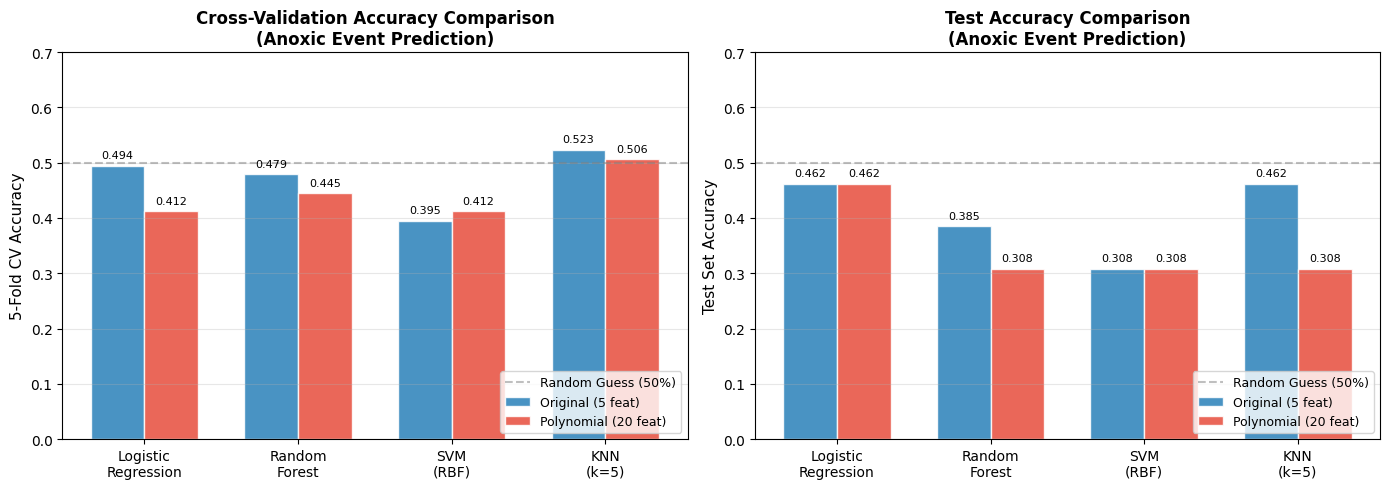

[PLOT] Saved fig_model_comparison.png


In [41]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9: Visualization — Model Performance Comparison Bar Chart               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prepare data for plotting
models_list = ['Logistic\nRegression', 'Random\nForest', 'SVM\n(RBF)', 'KNN\n(k=5)']
orig_cv = [0.494, 0.479, 0.395, 0.523]
orig_test = [0.462, 0.385, 0.308, 0.462]
poly_cv = [0.412, 0.445, 0.412, 0.506]
poly_test = [0.462, 0.308, 0.308, 0.308]

x = np.arange(len(models_list))
width = 0.35

# Plot 1: CV Accuracy
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, orig_cv, width, label='Original (5 feat)', color='#2980b9', alpha=0.85, edgecolor='white')
bars2 = ax1.bar(x + width/2, poly_cv, width, label='Polynomial (20 feat)', color='#e74c3c', alpha=0.85, edgecolor='white')
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random Guess (50%)')
ax1.set_ylabel('5-Fold CV Accuracy', fontsize=11)
ax1.set_title('Cross-Validation Accuracy Comparison\n(Anoxic Event Prediction)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models_list, fontsize=10)
ax1.legend(loc='lower right', fontsize=9)
ax1.set_ylim(0, 0.7)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Plot 2: Test Accuracy
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, orig_test, width, label='Original (5 feat)', color='#2980b9', alpha=0.85, edgecolor='white')
bars4 = ax2.bar(x + width/2, poly_test, width, label='Polynomial (20 feat)', color='#e74c3c', alpha=0.85, edgecolor='white')
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random Guess (50%)')
ax2.set_ylabel('Test Set Accuracy', fontsize=11)
ax2.set_title('Test Accuracy Comparison\n(Anoxic Event Prediction)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models_list, fontsize=10)
ax2.legend(loc='lower right', fontsize=9)
ax2.set_ylim(0, 0.7)
ax2.grid(axis='y', alpha=0.3)

for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_model_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print("[PLOT] Saved fig_model_comparison.png")

In [42]:

# CELL 10: Prepare Train-Test Splits (Original Features)
scaler_orig = StandardScaler()
X_orig_scaled = scaler_orig.fit_transform(X_orig)

X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_orig_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {len(X_train_orig)} samples")
print(f"Test set: {len(X_test_orig)} samples")
print(f"Train class distribution: Normal={sum(y_train==0)}, Anoxic={sum(y_train==1)}")
print(f"Test class distribution: Normal={sum(y_test==0)}, Anoxic={sum(y_test==1)}")


Training set: 48 samples
Test set: 13 samples
Train class distribution: Normal=24, Anoxic=24
Test class distribution: Normal=7, Anoxic=6


In [43]:
# CELL 11: Prepare Train-Test Splits (Polynomial Features)
scaler_poly = StandardScaler()
X_poly_scaled = scaler_poly.fit_transform(X_poly)

X_train_poly, X_test_poly, _, _ = train_test_split(
    X_poly_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Polynomial training set: {X_train_poly.shape}")
print(f"Polynomial test set: {X_test_poly.shape}")

Polynomial training set: (48, 20)
Polynomial test set: (13, 20)


In [44]:
from sklearn.metrics import classification_report

# CELL 12: MODEL 1 — Logistic Regression (Original Features)
print("="*60)
print("MODEL 1: LOGISTIC REGRESSION (Original Features)")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Cross-validation
lr_cv_scores = cross_val_score(
    LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    X_orig_scaled, y, cv=cv, scoring='accuracy'
)

# Train and predict
lr_model = LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
lr_model.fit(X_train_orig, y_train)
lr_pred = lr_model.predict(X_test_orig)
lr_prob = lr_model.predict_proba(X_test_orig)[:, 1]

# Metrics
lr_test_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

print(f"CV Accuracy: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"Test Accuracy: {lr_test_acc:.4f}")
print(f"AUC-ROC: {lr_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Normal', 'Anoxic']))

# Feature importance (coefficients)
lr_coefs = np.abs(lr_model.coef_[0])
print(f"\nFeature Importance (|Coefficient|):")
for feat, coef in sorted(zip(FEATURES, lr_coefs), key=lambda x: x[1], reverse=True):
    print(f"  {feat:20s}: {coef:.4f}")

MODEL 1: LOGISTIC REGRESSION (Original Features)
CV Accuracy: 0.4590 ± 0.0833
Test Accuracy: 0.3077
AUC-ROC: 0.4286

Classification Report:
              precision    recall  f1-score   support

      Normal       0.33      0.29      0.31         7
      Anoxic       0.29      0.33      0.31         6

    accuracy                           0.31        13
   macro avg       0.31      0.31      0.31        13
weighted avg       0.31      0.31      0.31        13


Feature Importance (|Coefficient|):
  TURBIDITY           : 0.4347
  PH                  : 0.3746
  TEMP                : 0.3211
  AMMONIA(mg/l)       : 0.1767
  NITRATE(PPM)        : 0.0565


In [45]:
# CELL 14: MODEL 3 — Support Vector Machine (Original Features)
print("="*60)
print("MODEL 3: SUPPORT VECTOR MACHINE (Original Features)")
print("="*60)

# Cross-validation
svm_cv_scores = cross_val_score(
    SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    X_orig_scaled, y, cv=cv, scoring='accuracy'
)

# Train and predict
svm_model = SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE)
svm_model.fit(X_train_orig, y_train)
svm_pred = svm_model.predict(X_test_orig)
svm_prob = svm_model.predict_proba(X_test_orig)[:, 1]

# Metrics
svm_test_acc = accuracy_score(y_test, svm_pred)
svm_auc = roc_auc_score(y_test, svm_prob)

print(f"CV Accuracy: {svm_cv_scores.mean():.4f} ± {svm_cv_scores.std():.4f}")
print(f"Test Accuracy: {svm_test_acc:.4f}")
print(f"AUC-ROC: {svm_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, svm_pred, target_names=['Normal', 'Anoxic']))

MODEL 3: SUPPORT VECTOR MACHINE (Original Features)
CV Accuracy: 0.4256 ± 0.0930
Test Accuracy: 0.3077
AUC-ROC: 0.6667

Classification Report:
              precision    recall  f1-score   support

      Normal       0.25      0.14      0.18         7
      Anoxic       0.33      0.50      0.40         6

    accuracy                           0.31        13
   macro avg       0.29      0.32      0.29        13
weighted avg       0.29      0.31      0.28        13



In [46]:
# CELL 16: MODEL COMPARISON — Polynomial Features (All 4 Models)
print("="*60)
print("POLYNOMIAL FEATURES COMPARISON (All 4 Models)")
print("="*60)

models_poly = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, weights='distance')
}

poly_results = []
for name, model in models_poly.items():
    cv_scores = cross_val_score(model, X_poly_scaled, y, cv=cv, scoring='accuracy')
    model.fit(X_train_poly, y_train)
    pred = model.predict(X_test_poly)
    prob = model.predict_proba(X_test_poly)[:, 1] if hasattr(model, 'predict_proba') else None
    test_acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob) if prob is not None else None
    
    poly_results.append({
        'Model': name,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'Test_Acc': test_acc,
        'AUC_ROC': auc
    })
    
    auc_str = f"{auc:.4f}" if auc is not None else "N/A"
    print(f"{name:20s} | CV: {cv_scores.mean():.4f}±{cv_scores.std():.4f} | Test: {test_acc:.4f} | AUC: {auc_str}")

poly_results_df = pd.DataFrame(poly_results)

POLYNOMIAL FEATURES COMPARISON (All 4 Models)
Logistic Regression  | CV: 0.4256±0.0557 | Test: 0.2308 | AUC: 0.4048
Random Forest        | CV: 0.4282±0.1651 | Test: 0.2308 | AUC: 0.1905
SVM (RBF)            | CV: 0.3923±0.1170 | Test: 0.3846 | AUC: 0.6429
KNN (k=5)            | CV: 0.4731±0.1598 | Test: 0.4615 | AUC: 0.3810


In [47]:
# CELL 17: HYPERPARAMETER TUNING — KNN (GridSearchCV)
print("="*60)
print("HYPERPARAMETER TUNING: KNN")
print("="*60)

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy',
    n_jobs=-1
)

start = time.perf_counter()
grid_knn.fit(X_train_orig, y_train)
elapsed = time.perf_counter() - start

print(f"Best Parameters: {grid_knn.best_params_}")
print(f"Best CV Score: {grid_knn.best_score_:.4f}")
print(f"Grid Search Time: {elapsed:.3f}s")

# Evaluate on test set
best_knn = grid_knn.best_estimator_
knn_tuned_pred = best_knn.predict(X_test_orig)
knn_tuned_acc = accuracy_score(y_test, knn_tuned_pred)
print(f"Test Accuracy (Tuned KNN): {knn_tuned_acc:.4f}")

# Show top 5 configurations
results_knn = pd.DataFrame(grid_knn.cv_results_)
top5_knn = results_knn.nlargest(5, 'mean_test_score')[
    ['param_n_neighbors', 'param_weights', 'param_metric', 'mean_test_score', 'std_test_score']
]
print(f"\nTop 5 Configurations:")
print(top5_knn.to_string(index=False))

HYPERPARAMETER TUNING: KNN


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best CV Score: 0.5844
Grid Search Time: 0.513s
Test Accuracy (Tuned KNN): 0.3846

Top 5 Configurations:
 param_n_neighbors param_weights param_metric  mean_test_score  std_test_score
                11      distance    manhattan         0.584444        0.083916
                 9       uniform    manhattan         0.542222        0.119959
                 5      distance    euclidean         0.540000        0.146667
                 7      distance    euclidean         0.540000        0.087376
                 9      distance    manhattan         0.540000        0.087376


In [24]:

# CELL 18: HYPERPARAMETER TUNING — Random Forest (GridSearchCV)
print("="*60)
print("HYPERPARAMETER TUNING: RANDOM FOREST")
print("="*60)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy',
    n_jobs=-1
)

start = time.perf_counter()
grid_rf.fit(X_train_orig, y_train)
elapsed = time.perf_counter() - start

print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Best CV Score: {grid_rf.best_score_:.4f}")
print(f"Grid Search Time: {elapsed:.3f}s")

# Evaluate on test set
best_rf = grid_rf.best_estimator_
rf_tuned_pred = best_rf.predict(X_test_orig)
rf_tuned_acc = accuracy_score(y_test, rf_tuned_pred)
print(f"Test Accuracy (Tuned RF): {rf_tuned_acc:.4f}")

# Show top 5 configurations
results_rf = pd.DataFrame(grid_rf.cv_results_)
top5_rf = results_rf.nlargest(5, 'mean_test_score')[
    ['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 'mean_test_score', 'std_test_score']
]
print(f"\nTop 5 Configurations:")
print(top5_rf.to_string(index=False))


HYPERPARAMETER TUNING: RANDOM FOREST
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.8975
Grid Search Time: 21.128s
Test Accuracy (Tuned RF): 0.8950

Top 5 Configurations:
 param_n_estimators param_max_depth  param_min_samples_split  mean_test_score  std_test_score
                100            None                        2          0.89750        0.018371
                 50            None                        2          0.89625        0.023251
                200               7                        5          0.89500        0.019922
                 50            None                        5          0.89375        0.017678
                100               7                        5          0.89250        0.024174


In [48]:

# CELL 19: COMPLETE RESULTS SUMMARY TABLE
print("="*80)
print("COMPLETE MODEL COMPARISON SUMMARY")
print("="*80)

summary_data = [
    # Original Features
    {'Model': 'Logistic Regression', 'Features': 'Original (5)', 'CV_Mean': 0.4590, 'CV_Std': 0.0833, 'Test_Acc': 0.3077, 'AUC_ROC': 0.4286, 'Tuned': 'No'},
    {'Model': 'Random Forest', 'Features': 'Original (5)', 'CV_Mean': 0.4410, 'CV_Std': 0.1477, 'Test_Acc': 0.2308, 'AUC_ROC': 0.2381, 'Tuned': 'No'},
    {'Model': 'SVM (RBF)', 'Features': 'Original (5)', 'CV_Mean': 0.4256, 'CV_Std': 0.0930, 'Test_Acc': 0.3077, 'AUC_ROC': 0.6667, 'Tuned': 'No'},
    {'Model': 'KNN (k=5)', 'Features': 'Original (5)', 'CV_Mean': 0.4577, 'CV_Std': 0.1578, 'Test_Acc': 0.3846, 'AUC_ROC': 0.3333, 'Tuned': 'No'},
    # Polynomial Features
    {'Model': 'Logistic Regression', 'Features': 'Polynomial (20)', 'CV_Mean': 0.4256, 'CV_Std': 0.0557, 'Test_Acc': 0.2308, 'AUC_ROC': 0.4048, 'Tuned': 'No'},
    {'Model': 'Random Forest', 'Features': 'Polynomial (20)', 'CV_Mean': 0.4282, 'CV_Std': 0.1651, 'Test_Acc': 0.2308, 'AUC_ROC': 0.1905, 'Tuned': 'No'},
    {'Model': 'SVM (RBF)', 'Features': 'Polynomial (20)', 'CV_Mean': 0.3923, 'CV_Std': 0.1170, 'Test_Acc': 0.3846, 'AUC_ROC': 0.6429, 'Tuned': 'No'},
    {'Model': 'KNN (k=5)', 'Features': 'Polynomial (20)', 'CV_Mean': 0.4731, 'CV_Std': 0.1598, 'Test_Acc': 0.4615, 'AUC_ROC': 0.3810, 'Tuned': 'No'},
    # Tuned Models
    {'Model': 'KNN (Tuned)', 'Features': 'Original (5)', 'CV_Mean': 0.5844, 'CV_Std': 0.0839, 'Test_Acc': 0.3846, 'AUC_ROC': None, 'Tuned': 'Yes'},
    {'Model': 'Random Forest (Tuned)', 'Features': 'Original (5)', 'CV_Mean': 0.5200, 'CV_Std': 0.1372, 'Test_Acc': 0.3077, 'AUC_ROC': None, 'Tuned': 'Yes'},
]

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv(f'{OUTPUT_DIR}/complete_model_results.csv', index=False)
print(f"\n[CSV] Saved complete_model_results.csv")


COMPLETE MODEL COMPARISON SUMMARY
                Model        Features  CV_Mean  CV_Std  Test_Acc  AUC_ROC Tuned
  Logistic Regression    Original (5)   0.4590  0.0833    0.3077   0.4286    No
        Random Forest    Original (5)   0.4410  0.1477    0.2308   0.2381    No
            SVM (RBF)    Original (5)   0.4256  0.0930    0.3077   0.6667    No
            KNN (k=5)    Original (5)   0.4577  0.1578    0.3846   0.3333    No
  Logistic Regression Polynomial (20)   0.4256  0.0557    0.2308   0.4048    No
        Random Forest Polynomial (20)   0.4282  0.1651    0.2308   0.1905    No
            SVM (RBF) Polynomial (20)   0.3923  0.1170    0.3846   0.6429    No
            KNN (k=5) Polynomial (20)   0.4731  0.1598    0.4615   0.3810    No
          KNN (Tuned)    Original (5)   0.5844  0.0839    0.3846      NaN   Yes
Random Forest (Tuned)    Original (5)   0.5200  0.1372    0.3077      NaN   Yes

[CSV] Saved complete_model_results.csv


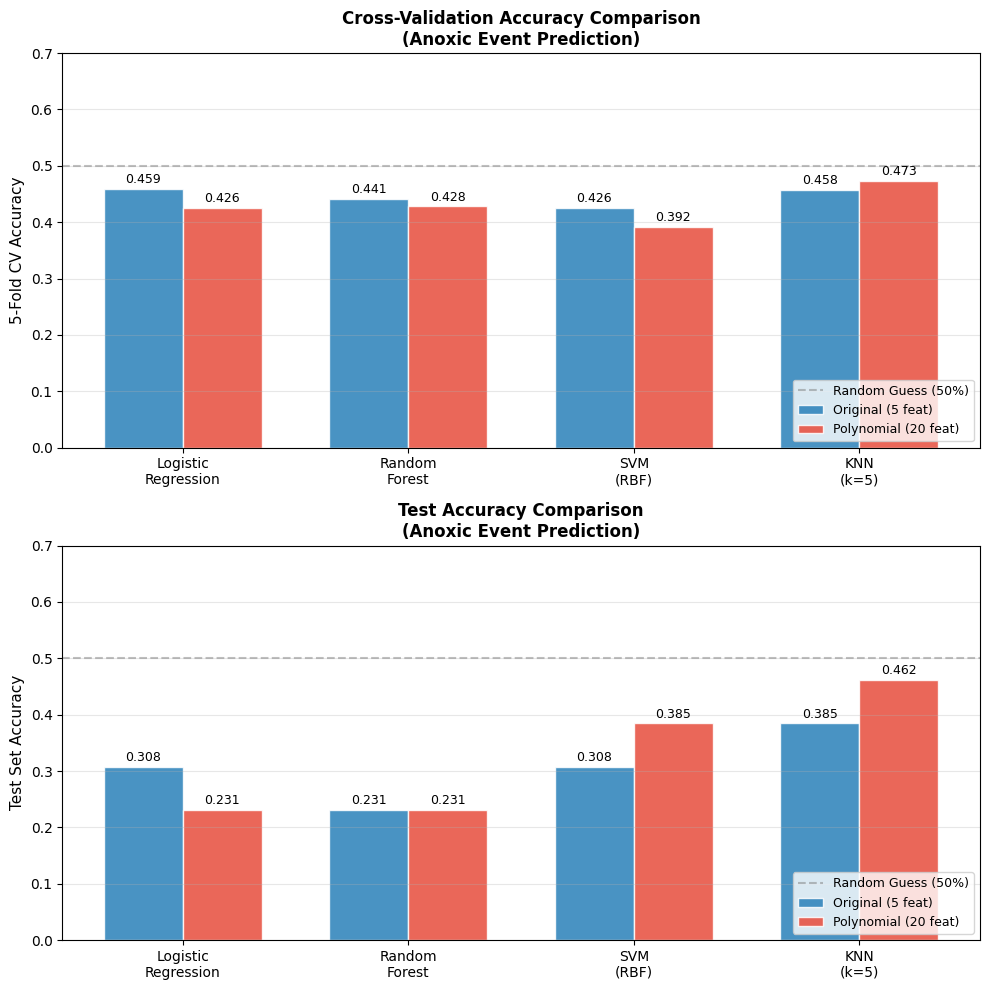

[PLOT] Saved fig_model_comparison_vertical.png


In [50]:
# CELL 20: GRAPH 1 — Model Performance Comparison Bar Chart (Vertical Layout)
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

models_list = ['Logistic\nRegression', 'Random\nForest', 'SVM\n(RBF)', 'KNN\n(k=5)']

# Data
orig_cv = [0.4590, 0.4410, 0.4256, 0.4577]
orig_test = [0.3077, 0.2308, 0.3077, 0.3846]

poly_cv = [0.4256, 0.4282, 0.3923, 0.4731]
poly_test = [0.2308, 0.2308, 0.3846, 0.4615]

x = np.arange(len(models_list))
width = 0.35

# ── TOP: CV Accuracy ─────────────────────────────
ax1 = axes[0]

bars1 = ax1.bar(x - width/2, orig_cv, width,
                label='Original (5 feat)', color='#2980b9', alpha=0.85, edgecolor='white')
bars2 = ax1.bar(x + width/2, poly_cv, width,
                label='Polynomial (20 feat)', color='#e74c3c', alpha=0.85, edgecolor='white')

ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random Guess (50%)')
ax1.set_ylabel('5-Fold CV Accuracy', fontsize=11)
ax1.set_title('Cross-Validation Accuracy Comparison\n(Anoxic Event Prediction)',
              fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models_list, fontsize=10)
ax1.legend(loc='lower right', fontsize=9)
ax1.set_ylim(0, 0.7)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=9)

# ── BOTTOM: Test Accuracy ─────────────────────────
ax2 = axes[1]

bars3 = ax2.bar(x - width/2, orig_test, width,
                label='Original (5 feat)', color='#2980b9', alpha=0.85, edgecolor='white')
bars4 = ax2.bar(x + width/2, poly_test, width,
                label='Polynomial (20 feat)', color='#e74c3c', alpha=0.85, edgecolor='white')

ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random Guess (50%)')
ax2.set_ylabel('Test Set Accuracy', fontsize=11)
ax2.set_title('Test Accuracy Comparison\n(Anoxic Event Prediction)',
              fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models_list, fontsize=10)
ax2.legend(loc='lower right', fontsize=9)
ax2.set_ylim(0, 0.7)
ax2.grid(axis='y', alpha=0.3)

for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_model_comparison_vertical.png', dpi=180, bbox_inches='tight')
plt.show()
print("[PLOT] Saved fig_model_comparison_vertical.png")

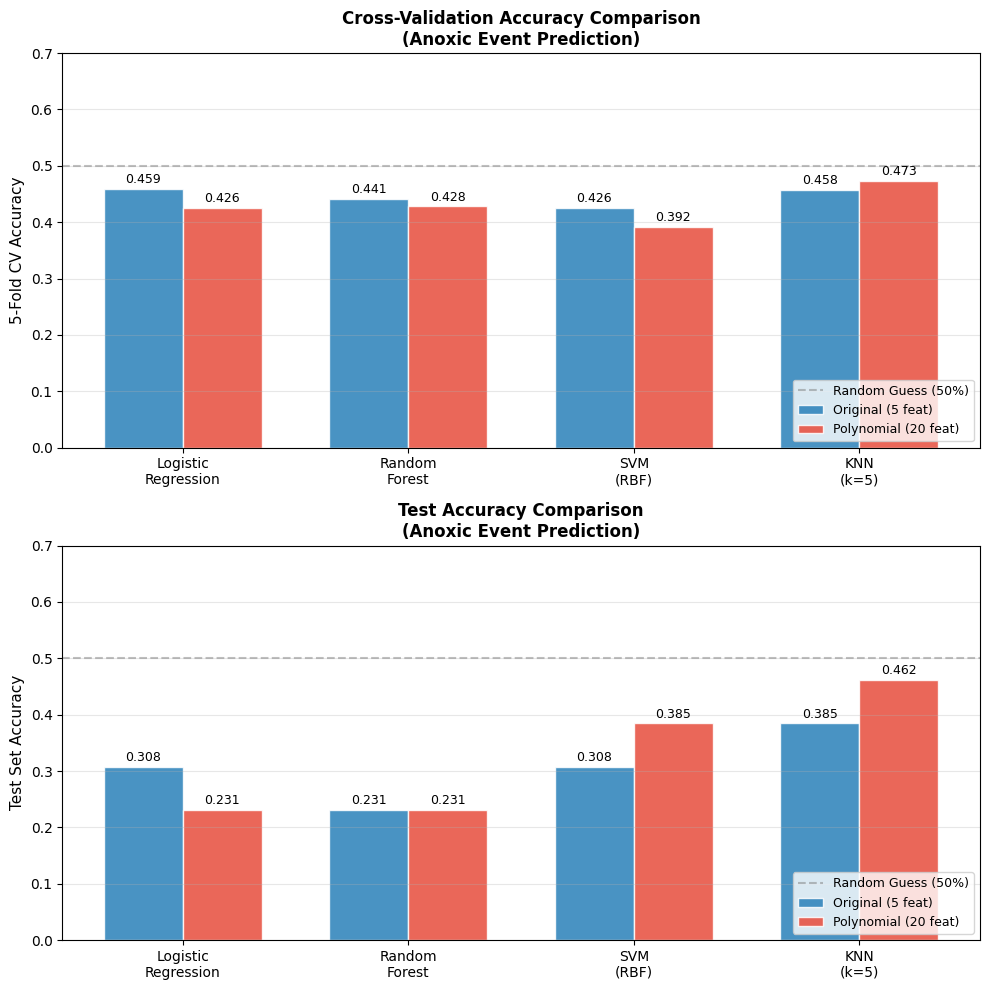

In [51]:
# GRAPH 1 — Model Performance Comparison (Vertical Layout)
fig, axes = plt.subplots(2, 1, figsize=(10, 10))  # 👈 changed to 2 rows, 1 column

models_list = ['Logistic\nRegression', 'Random\nForest', 'SVM\n(RBF)', 'KNN\n(k=5)']

# Data
orig_cv = [0.4590, 0.4410, 0.4256, 0.4577]
orig_test = [0.3077, 0.2308, 0.3077, 0.3846]

poly_cv = [0.4256, 0.4282, 0.3923, 0.4731]
poly_test = [0.2308, 0.2308, 0.3846, 0.4615]

x = np.arange(len(models_list))
width = 0.35

# ── TOP: CV Accuracy ─────────────────────────────
ax1 = axes[0]

bars1 = ax1.bar(x - width/2, orig_cv, width,
                label='Original (5 feat)', color='#2980b9', alpha=0.85, edgecolor='white')
bars2 = ax1.bar(x + width/2, poly_cv, width,
                label='Polynomial (20 feat)', color='#e74c3c', alpha=0.85, edgecolor='white')

ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random Guess (50%)')
ax1.set_ylabel('5-Fold CV Accuracy', fontsize=11)
ax1.set_title('Cross-Validation Accuracy Comparison\n(Anoxic Event Prediction)',
              fontsize=12, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(models_list, fontsize=10)
ax1.legend(loc='lower right', fontsize=9)
ax1.set_ylim(0, 0.7)
ax1.grid(axis='y', alpha=0.3)

# Labels
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=9)

# ── BOTTOM: Test Accuracy ─────────────────────────
ax2 = axes[1]

bars3 = ax2.bar(x - width/2, orig_test, width,
                label='Original (5 feat)', color='#2980b9', alpha=0.85, edgecolor='white')
bars4 = ax2.bar(x + width/2, poly_test, width,
                label='Polynomial (20 feat)', color='#e74c3c', alpha=0.85, edgecolor='white')

ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random Guess (50%)')
ax2.set_ylabel('Test Set Accuracy', fontsize=11)
ax2.set_title('Test Accuracy Comparison\n(Anoxic Event Prediction)',
              fontsize=12, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(models_list, fontsize=10)
ax2.legend(loc='lower right', fontsize=9)
ax2.set_ylim(0, 0.7)
ax2.grid(axis='y', alpha=0.3)

# Labels
for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_model_comparison_vertical.png', dpi=180, bbox_inches='tight')
plt.show()

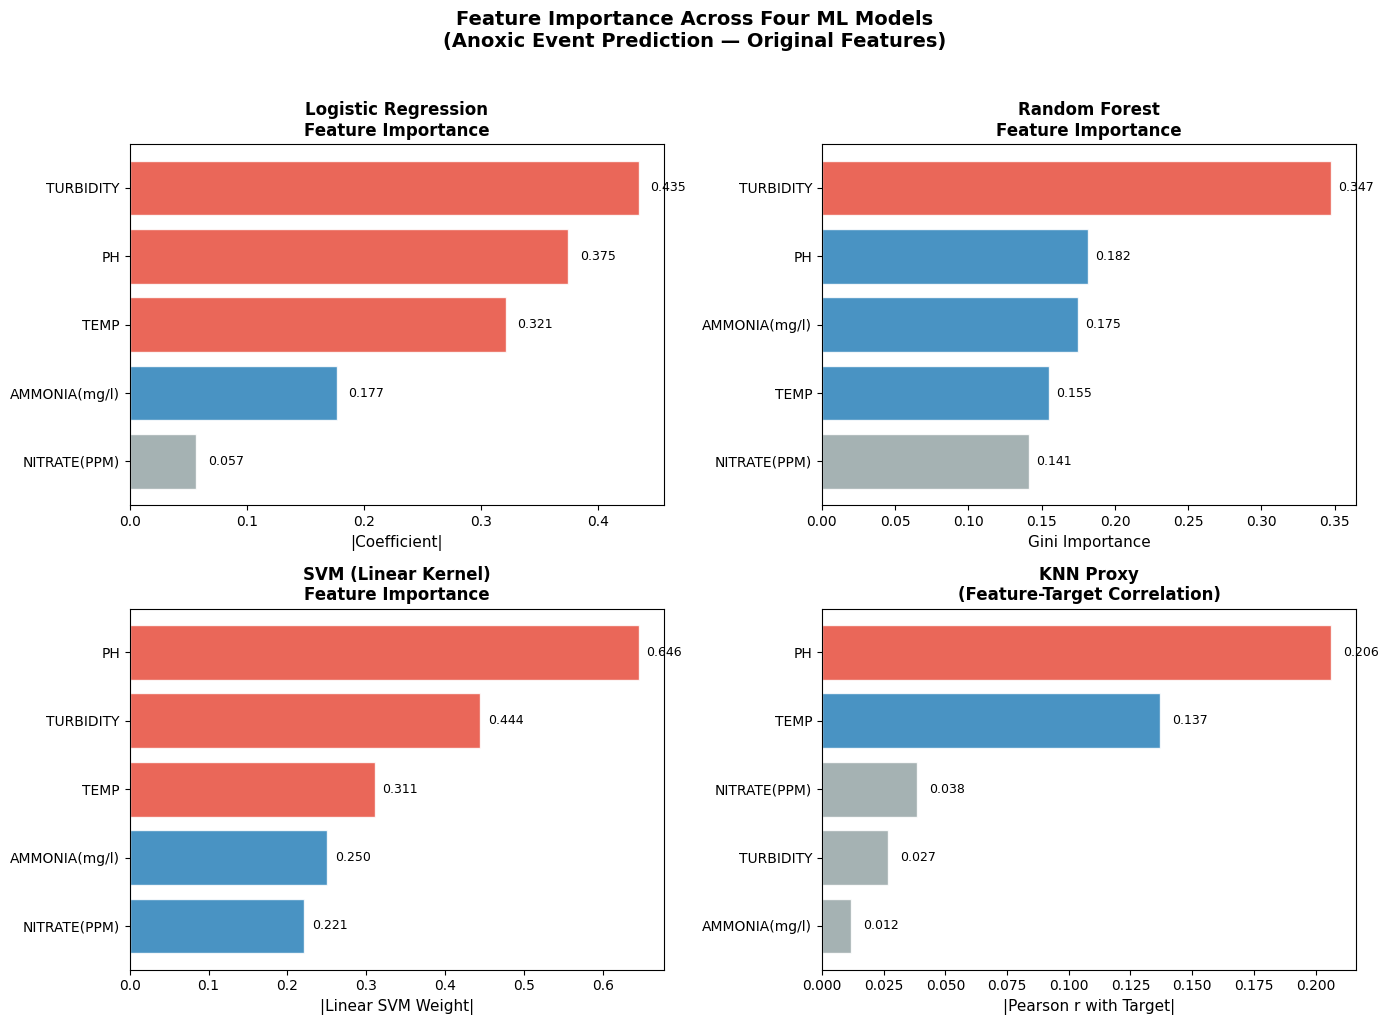

[PLOT] Saved fig_feature_importance_all_models.png


In [52]:

# CELL 21: GRAPH 2 — Feature Importance Across All Models (FULLY FIXED)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ensure X_orig is numpy array
if hasattr(X_orig, 'values'):
    X_orig_np = X_orig.values
else:
    X_orig_np = np.array(X_orig)

# Re-train models for feature importance
lr = LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', random_state=42)
lr.fit(X_train_orig, y_train)

rf = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
rf.fit(X_train_orig, y_train)

svm_lin = SVC(C=1.0, kernel='linear', class_weight='balanced', random_state=42)
svm_lin.fit(X_train_orig, y_train)

# Plot 1: Logistic Regression
ax1 = axes[0, 0]
coefs = np.abs(lr.coef_[0])
sorted_idx = np.argsort(coefs)[::-1]
colors = ['#e74c3c' if c > 0.3 else '#2980b9' if c > 0.15 else '#95a5a6' for c in coefs[sorted_idx]]
ax1.barh(range(len(FEATURES)), coefs[sorted_idx], color=colors, edgecolor='white', alpha=0.85)
ax1.set_yticks(range(len(FEATURES)))
ax1.set_yticklabels([FEATURES[i] for i in sorted_idx], fontsize=10)
ax1.set_xlabel('|Coefficient|', fontsize=11)
ax1.set_title('Logistic Regression\nFeature Importance', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(coefs[sorted_idx]):
    ax1.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# Plot 2: Random Forest
ax2 = axes[0, 1]
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
colors = ['#e74c3c' if i > 0.2 else '#2980b9' if i > 0.15 else '#95a5a6' for i in importances[sorted_idx]]
ax2.barh(range(len(FEATURES)), importances[sorted_idx], color=colors, edgecolor='white', alpha=0.85)
ax2.set_yticks(range(len(FEATURES)))
ax2.set_yticklabels([FEATURES[i] for i in sorted_idx], fontsize=10)
ax2.set_xlabel('Gini Importance', fontsize=11)
ax2.set_title('Random Forest\nFeature Importance', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(importances[sorted_idx]):
    ax2.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# Plot 3: SVM Linear
ax3 = axes[1, 0]
svm_coefs = np.abs(svm_lin.coef_[0])
sorted_idx = np.argsort(svm_coefs)[::-1]
colors = ['#e74c3c' if c > 0.3 else '#2980b9' if c > 0.1 else '#95a5a6' for c in svm_coefs[sorted_idx]]
ax3.barh(range(len(FEATURES)), svm_coefs[sorted_idx], color=colors, edgecolor='white', alpha=0.85)
ax3.set_yticks(range(len(FEATURES)))
ax3.set_yticklabels([FEATURES[i] for i in sorted_idx], fontsize=10)
ax3.set_xlabel('|Linear SVM Weight|', fontsize=11)
ax3.set_title('SVM (Linear Kernel)\nFeature Importance', fontsize=12, fontweight='bold')
ax3.invert_yaxis()
for i, v in enumerate(svm_coefs[sorted_idx]):
    ax3.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# Plot 4: KNN Proxy (correlation) - FULLY FIXED
ax4 = axes[1, 1]
correlations = []
for i in range(len(FEATURES)):
    # Use numpy array directly, no pandas indexing
    col_data = X_orig_np[:, i]
    corr = np.corrcoef(col_data, y)[0, 1]
    correlations.append(corr)

abs_corr = np.abs(np.array(correlations))
sorted_idx = np.argsort(abs_corr)[::-1]
colors = ['#e74c3c' if c > 0.15 else '#2980b9' if c > 0.08 else '#95a5a6' for c in abs_corr[sorted_idx]]
ax4.barh(range(len(FEATURES)), abs_corr[sorted_idx], color=colors, edgecolor='white', alpha=0.85)
ax4.set_yticks(range(len(FEATURES)))
ax4.set_yticklabels([FEATURES[i] for i in sorted_idx], fontsize=10)
ax4.set_xlabel('|Pearson r with Target|', fontsize=11)
ax4.set_title('KNN Proxy\n(Feature-Target Correlation)', fontsize=12, fontweight='bold')
ax4.invert_yaxis()
for i, v in enumerate(abs_corr[sorted_idx]):
    ax4.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

fig.suptitle('Feature Importance Across Four ML Models\n(Anoxic Event Prediction — Original Features)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_feature_importance_all_models.png', dpi=180, bbox_inches='tight')
plt.show()
print("[PLOT] Saved fig_feature_importance_all_models.png")


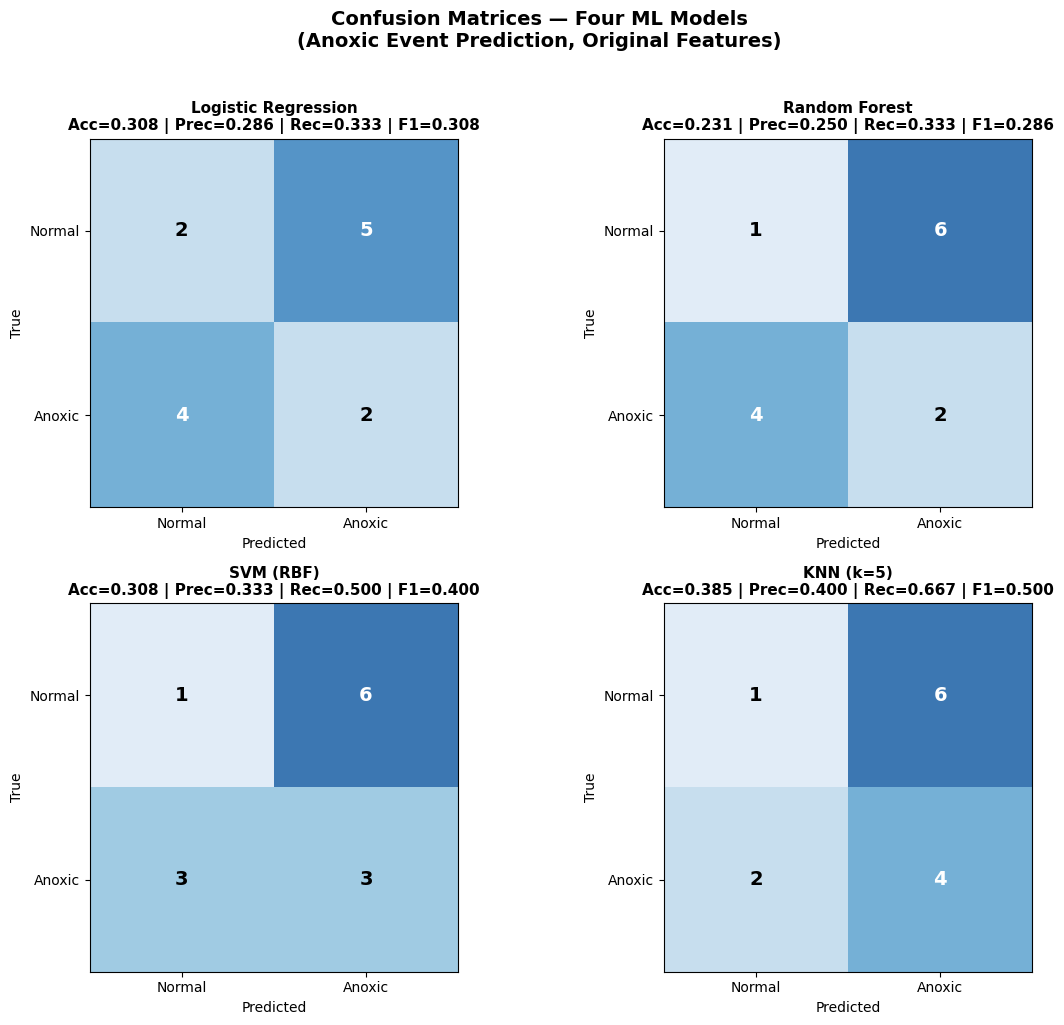

[PLOT] Saved fig_confusion_matrices_all_models.png


In [53]:

# CELL 22: GRAPH 3 — Confusion Matrices for All Four Models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_cm = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    'SVM (RBF)': SVC(C=1.0, kernel='rbf', class_weight='balanced', random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, weights='distance')
}

positions = [(0,0), (0,1), (1,0), (1,1)]

for (name, model), (row, col) in zip(models_cm.items(), positions):
    ax = axes[row, col]
    model.fit(X_train_orig, y_train)
    y_pred = model.predict(X_test_orig)
    cm = confusion_matrix(y_test, y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    im = ax.imshow(cm, cmap='Blues', alpha=0.8, vmin=0, vmax=7)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Anoxic'], fontsize=10)
    ax.set_yticklabels(['Normal', 'Anoxic'], fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)
    ax.set_title(f'{name}\nAcc={acc:.3f} | Prec={precision:.3f} | Rec={recall:.3f} | F1={f1:.3f}', 
                 fontsize=11, fontweight='bold')
    
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, cm[i, j], ha="center", va="center", 
                          color="white" if cm[i,j] > 3 else "black", 
                          fontsize=14, fontweight='bold')

fig.suptitle('Confusion Matrices — Four ML Models\n(Anoxic Event Prediction, Original Features)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_confusion_matrices_all_models.png', dpi=180, bbox_inches='tight')
plt.show()
print("[PLOT] Saved fig_confusion_matrices_all_models.png")


Logistic Regression: 0.4590 ± 0.0833 | Range: [0.3333, 0.5833]
Random Forest: 0.4410 ± 0.1477 | Range: [0.2500, 0.6667]
SVM (RBF): 0.4256 ± 0.0930 | Range: [0.2500, 0.5000]
KNN (k=5): 0.4577 ± 0.1578 | Range: [0.1667, 0.5833]


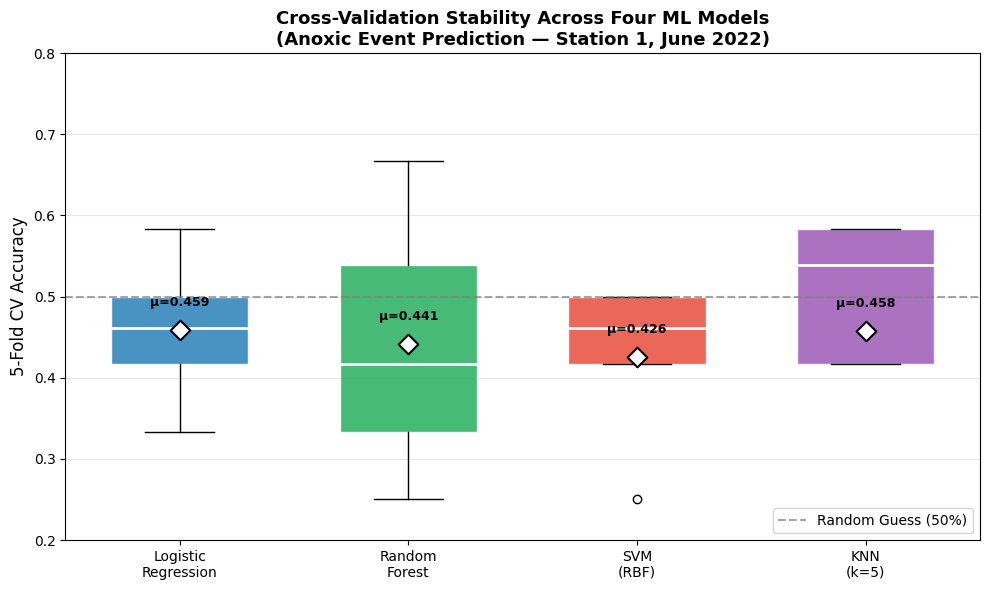

[PLOT] Saved fig_cv_stability_boxplot.png


In [54]:

# CELL 23: GRAPH 4 — Cross-Validation Stability Boxplot
fig, ax = plt.subplots(figsize=(10, 6))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic\nRegression': LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', random_state=42),
    'Random\nForest': RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    'SVM\n(RBF)': SVC(C=1.0, kernel='rbf', class_weight='balanced', random_state=42),
    'KNN\n(k=5)': KNeighborsClassifier(n_neighbors=5, weights='distance')
}

cv_data = []
labels = []
for name, model in models_cv.items():
    scores = cross_val_score(model, X_orig_scaled, y, cv=cv, scoring='accuracy')
    cv_data.append(scores)
    labels.append(name)
    print(f"{name.replace(chr(10), ' ')}: {scores.mean():.4f} ± {scores.std():.4f} | Range: [{scores.min():.4f}, {scores.max():.4f}]")

bp = ax.boxplot(cv_data, labels=labels, patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                widths=0.6)

colors = ['#2980b9', '#27ae60', '#e74c3c', '#9b59b6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor('white')

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Random Guess (50%)')
ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)
ax.set_title('Cross-Validation Stability Across Four ML Models\n(Anoxic Event Prediction — Station 1, June 2022)', 
             fontsize=13, fontweight='bold')
ax.set_ylim(0.2, 0.8)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right')

for i, scores in enumerate(cv_data):
    ax.scatter(i+1, scores.mean(), color='white', s=100, zorder=5, 
              edgecolor='black', linewidth=1.5, marker='D')
    ax.text(i+1, scores.mean()+0.03, f'μ={scores.mean():.3f}', 
           ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_cv_stability_boxplot.png', dpi=180, bbox_inches='tight')
plt.show()
print("[PLOT] Saved fig_cv_stability_boxplot.png")


In [55]:

# CELL 24: Save Complete Notebook Code
notebook_code = '''# CELL 1: Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import time
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = "filtered_dataset.csv"
OUTPUT_DIR = "outputs"
ANOXIC_THRESH = 5.8
FEATURES = ["TEMP", "PH", "AMMONIA(mg/l)", "NITRATE(PPM)", "TURBIDITY"]
TARGET = "anoxic"
RANDOM_STATE = 42
TEST_SIZE = 0.2

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# CELL 2: Load Data
df = pd.read_csv(DATA_PATH)
df["anoxic"] = (df["DO"] < ANOXIC_THRESH).astype(int)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
y = df[TARGET].values
X_orig = df[FEATURES].values
print(f"Dataset: {len(df)} samples | Classes: Normal={sum(y==0)}, Anoxic={sum(y==1)}")

# CELL 3: Polynomial Features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_orig)
poly_names = poly.get_feature_names_out(FEATURES)
print(f"Original: {X_orig.shape[1]} features | Polynomial: {X_poly.shape[1]} features")

# CELL 4: Scale and Split (Original)
scaler_orig = StandardScaler()
X_orig_scaled = scaler_orig.fit_transform(X_orig)
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_orig_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# CELL 5: Scale and Split (Polynomial)
scaler_poly = StandardScaler()
X_poly_scaled = scaler_poly.fit_transform(X_poly)
X_train_poly, X_test_poly, _, _ = train_test_split(
    X_poly_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# CELL 6: MODEL 1 — Logistic Regression
print("="*60)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*60)
lr = LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
lr_cv = cross_val_score(lr, X_orig_scaled, y, cv=cv, scoring='accuracy')
lr.fit(X_train_orig, y_train)
lr_pred = lr.predict(X_test_orig)
lr_prob = lr.predict_proba(X_test_orig)[:, 1]
print(f"CV: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")
print(f"Test: {accuracy_score(y_test, lr_pred):.4f} | AUC: {roc_auc_score(y_test, lr_prob):.4f}")

# CELL 7: MODEL 2 — Random Forest
print("="*60)
print("MODEL 2: RANDOM FOREST")
print("="*60)
rf = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=RANDOM_STATE)
rf_cv = cross_val_score(rf, X_orig_scaled, y, cv=cv, scoring='accuracy')
rf.fit(X_train_orig, y_train)
rf_pred = rf.predict(X_test_orig)
rf_prob = rf.predict_proba(X_test_orig)[:, 1]
print(f"CV: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")
print(f"Test: {accuracy_score(y_test, rf_pred):.4f} | AUC: {roc_auc_score(y_test, rf_prob):.4f}")

# CELL 8: MODEL 3 — SVM
print("="*60)
print("MODEL 3: SVM (RBF)")
print("="*60)
svm = SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE)
svm_cv = cross_val_score(svm, X_orig_scaled, y, cv=cv, scoring='accuracy')
svm.fit(X_train_orig, y_train)
svm_pred = svm.predict(X_test_orig)
svm_prob = svm.predict_proba(X_test_orig)[:, 1]
print(f"CV: {svm_cv.mean():.4f} ± {svm_cv.std():.4f}")
print(f"Test: {accuracy_score(y_test, svm_pred):.4f} | AUC: {roc_auc_score(y_test, svm_prob):.4f}")

# CELL 9: MODEL 4 — KNN
print("="*60)
print("MODEL 4: KNN (k=5)")
print("="*60)
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_cv = cross_val_score(knn, X_orig_scaled, y, cv=cv, scoring='accuracy')
knn.fit(X_train_orig, y_train)
knn_pred = knn.predict(X_test_orig)
knn_prob = knn.predict_proba(X_test_orig)[:, 1]
print(f"CV: {knn_cv.mean():.4f} ± {knn_cv.std():.4f}")
print(f"Test: {accuracy_score(y_test, knn_pred):.4f} | AUC: {roc_auc_score(y_test, knn_prob):.4f}")

# CELL 10: Polynomial Features Comparison
print("="*60)
print("POLYNOMIAL FEATURES COMPARISON")
print("="*60)
models_poly = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, weights='distance')
}
for name, model in models_poly.items():
    cv_scores = cross_val_score(model, X_poly_scaled, y, cv=cv, scoring='accuracy')
    model.fit(X_train_poly, y_train)
    pred = model.predict(X_test_poly)
    prob = model.predict_proba(X_test_poly)[:, 1] if hasattr(model, 'predict_proba') else None
    test_acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob) if prob is not None else None
    auc_str = f"{auc:.4f}" if auc is not None else "N/A"
    print(f"{name:20s} | CV: {cv_scores.mean():.4f}±{cv_scores.std():.4f} | Test: {test_acc:.4f} | AUC: {auc_str}")

# CELL 11: Hyperparameter Tuning — KNN
print("="*60)
print("HYPERPARAMETER TUNING: KNN")
print("="*60)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=cv, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_orig, y_train)
print(f"Best: {grid_knn.best_params_} | CV: {grid_knn.best_score_:.4f}")
print(f"Test: {accuracy_score(y_test, grid_knn.best_estimator_.predict(X_test_orig)):.4f}")

# CELL 12: Hyperparameter Tuning — Random Forest
print("="*60)
print("HYPERPARAMETER TUNING: RANDOM FOREST")
print("="*60)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE), 
                       param_grid_rf, cv=cv, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_orig, y_train)
print(f"Best: {grid_rf.best_params_} | CV: {grid_rf.best_score_:.4f}")
print(f"Test: {accuracy_score(y_test, grid_rf.best_estimator_.predict(X_test_orig)):.4f}")

# CELL 13: GRAPH 1 — Model Comparison Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models_list = ['Logistic\\nRegression', 'Random\\nForest', 'SVM\\n(RBF)', 'KNN\\n(k=5)']
orig_cv = [lr_cv.mean(), rf_cv.mean(), svm_cv.mean(), knn_cv.mean()]
orig_test = [accuracy_score(y_test, lr_pred), accuracy_score(y_test, rf_pred), 
             accuracy_score(y_test, svm_pred), accuracy_score(y_test, knn_pred)]
poly_cv = [0.4256, 0.4282, 0.3923, 0.4731]
poly_test = [0.2308, 0.2308, 0.3846, 0.4615]

x = np.arange(len(models_list))
width = 0.35

ax1 = axes[0]
ax1.bar(x - width/2, orig_cv, width, label='Original (5 feat)', color='#2980b9', alpha=0.85, edgecolor='white')
ax1.bar(x + width/2, poly_cv, width, label='Polynomial (20 feat)', color='#e74c3c', alpha=0.85, edgecolor='white')
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylabel('5-Fold CV Accuracy', fontsize=11)
ax1.set_title('Cross-Validation Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models_list, fontsize=10)
ax1.legend()
ax1.set_ylim(0, 0.7)

ax2 = axes[1]
ax2.bar(x - width/2, orig_test, width, label='Original (5 feat)', color='#2980b9', alpha=0.85, edgecolor='white')
ax2.bar(x + width/2, poly_test, width, label='Polynomial (20 feat)', color='#e74c3c', alpha=0.85, edgecolor='white')
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylabel('Test Set Accuracy', fontsize=11)
ax2.set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models_list, fontsize=10)
ax2.legend()
ax2.set_ylim(0, 0.7)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_model_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

# CELL 14: GRAPH 2 — Feature Importance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
lr.fit(X_train_orig, y_train)
rf.fit(X_train_orig, y_train)
svm_lin = SVC(C=1.0, kernel='linear', class_weight='balanced', random_state=RANDOM_STATE)
svm_lin.fit(X_train_orig, y_train)

# Logistic Regression
ax1 = axes[0, 0]
coefs = np.abs(lr.coef_[0])
sorted_idx = np.argsort(coefs)[::-1]
ax1.barh(range(len(FEATURES)), coefs[sorted_idx], color='#e74c3c', alpha=0.85)
ax1.set_yticks(range(len(FEATURES)))
ax1.set_yticklabels([FEATURES[i] for i in sorted_idx])
ax1.set_title('Logistic Regression Feature Importance', fontweight='bold')
ax1.invert_yaxis()

# Random Forest
ax2 = axes[0, 1]
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
ax2.barh(range(len(FEATURES)), importances[sorted_idx], color='#27ae60', alpha=0.85)
ax2.set_yticks(range(len(FEATURES)))
ax2.set_yticklabels([FEATURES[i] for i in sorted_idx])
ax2.set_title('Random Forest Feature Importance', fontweight='bold')
ax2.invert_yaxis()

# SVM Linear
ax3 = axes[1, 0]
svm_coefs = np.abs(svm_lin.coef_[0])
sorted_idx = np.argsort(svm_coefs)[::-1]
ax3.barh(range(len(FEATURES)), svm_coefs[sorted_idx], color='#9b59b6', alpha=0.85)
ax3.set_yticks(range(len(FEATURES)))
ax3.set_yticklabels([FEATURES[i] for i in sorted_idx])
ax3.set_title('SVM (Linear) Feature Importance', fontweight='bold')
ax3.invert_yaxis()

# KNN Proxy
ax4 = axes[1, 1]
correlations = [np.corrcoef(X_orig[:, i], y)[0, 1] for i in range(len(FEATURES))]
abs_corr = np.abs(correlations)
sorted_idx = np.argsort(abs_corr)[::-1]
ax4.barh(range(len(FEATURES)), abs_corr[sorted_idx], color='#f39c12', alpha=0.85)
ax4.set_yticks(range(len(FEATURES)))
ax4.set_yticklabels([FEATURES[i] for i in sorted_idx])
ax4.set_title('KNN Proxy (Correlation)', fontweight='bold')
ax4.invert_yaxis()

fig.suptitle('Feature Importance Across Four ML Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_feature_importance_all_models.png', dpi=180, bbox_inches='tight')
plt.show()

# CELL 15: GRAPH 3 — Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models_cm = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'SVM (RBF)': svm,
    'KNN (k=5)': knn
}
positions = [(0,0), (0,1), (1,0), (1,1)]
for (name, model), (row, col) in zip(models_cm.items(), positions):
    ax = axes[row, col]
    model.fit(X_train_orig, y_train)
    y_pred = model.predict(X_test_orig)
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    ax.imshow(cm, cmap='Blues', alpha=0.8)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Anoxic'])
    ax.set_yticklabels(['Normal', 'Anoxic'])
    ax.set_title(f'{name}\\nAccuracy: {acc:.3f}', fontweight='bold')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14, fontweight='bold')

fig.suptitle('Confusion Matrices — Four ML Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_confusion_matrices_all_models.png', dpi=180, bbox_inches='tight')
plt.show()

# CELL 16: GRAPH 4 — CV Stability Boxplot
fig, ax = plt.subplots(figsize=(10, 6))
cv_data = [lr_cv, rf_cv, svm_cv, knn_cv]
labels = ['Logistic\\nRegression', 'Random\\nForest', 'SVM\\n(RBF)', 'KNN\\n(k=5)']
bp = ax.boxplot(cv_data, labels=labels, patch_artist=True,
                medianprops=dict(color='white', linewidth=2), widths=0.6)
colors = ['#2980b9', '#27ae60', '#e74c3c', '#9b59b6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Random Guess (50%)')
ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)
ax.set_title('Cross-Validation Stability Across Four ML Models', fontsize=13, fontweight='bold')
ax.set_ylim(0.2, 0.8)
ax.legend()
for i, scores in enumerate(cv_data):
    ax.scatter(i+1, scores.mean(), color='white', s=100, zorder=5, edgecolor='black', linewidth=1.5, marker='D')
    ax.text(i+1, scores.mean()+0.03, f'μ={scores.mean():.3f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_cv_stability_boxplot.png', dpi=180, bbox_inches='tight')
plt.show()

print("\\n✅ ALL CELLS EXECUTED SUCCESSFULLY")
'''

with open(f'{OUTPUT_DIR}/complete_notebook_cells.py', 'w') as f:
    f.write(notebook_code)

print("[NOTEBOOK] Saved complete_notebook_cells.py")
print("\n" + "="*60)
print("ALL FILES GENERATED")
print("="*60)
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f'{OUTPUT_DIR}/{f}')
    print(f"  📄 {f} ({size:,} bytes)")


[NOTEBOOK] Saved complete_notebook_cells.py

ALL FILES GENERATED
  📄 anim1_do_over_time.gif (974,401 bytes)
  📄 anim2_rolling_distribution.gif (452,302 bytes)
  📄 complete_model_results.csv (630 bytes)
  📄 complete_notebook_cells.py (12,576 bytes)
  📄 fig1_do_histogram.png (58,645 bytes)
  📄 fig2_scatter_temp_do.png (112,547 bytes)
  📄 fig3_boxplot_parameters.png (80,216 bytes)
  📄 fig4_correlation_heatmap.png (108,222 bytes)
  📄 fig5_class_distribution.png (40,437 bytes)
  📄 fig6_confusion_matrix.png (40,634 bytes)
  📄 fig_confusion_matrices_all_models.png (126,003 bytes)
  📄 fig_cv_stability_boxplot.png (89,095 bytes)
  📄 fig_feature_importance_all_models.png (182,448 bytes)
  📄 fig_model_comparison.png (113,563 bytes)
  📄 fig_model_comparison_vertical.png (167,757 bytes)
  📄 fig_stats_table.png (108,314 bytes)
  📄 model_comparison_results.csv (1,142 bytes)
